In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [2]:
#____________________________ part a ______________________________#
from sklearn.datasets import fetch_openml
import numpy as np

# Loading MNIST dataset
mnist = fetch_openml('mnist_784')
X, y = mnist.data, mnist.target
y = np.array(X.mask(X != 0, 1).astype('int'))


In [3]:
#____________________________ part b ______________________________#
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = np.array(X).astype('float32')

scaler=MinMaxScaler()
X=scaler.fit_transform(X)

# Adding random noise to the images
noise_factor = 0.25
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

# Clipping pixel values to range [0, 1]
X_noisy = np.clip(X_noisy, 0., 1.)

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.2, random_state=15)


In [4]:
#____________________________ part d ______________________________#
from sklearn.neighbors import KNeighborsClassifier

# Training a KNN model
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)


KNeighborsClassifier()

(-0.5, 27.5, 27.5, -0.5)

Text(0.5, 1.0, 'Noisy image')

(-0.5, 27.5, 27.5, -0.5)

Text(0.5, 1.0, 'Restored image')

(-0.5, 27.5, 27.5, -0.5)

...

Text(0.5, 1.0, 'Restored image')

(-0.5, 27.5, 27.5, -0.5)

Text(0.5, 1.0, 'Noisy image')

(-0.5, 27.5, 27.5, -0.5)

Text(0.5, 1.0, 'Restored image')

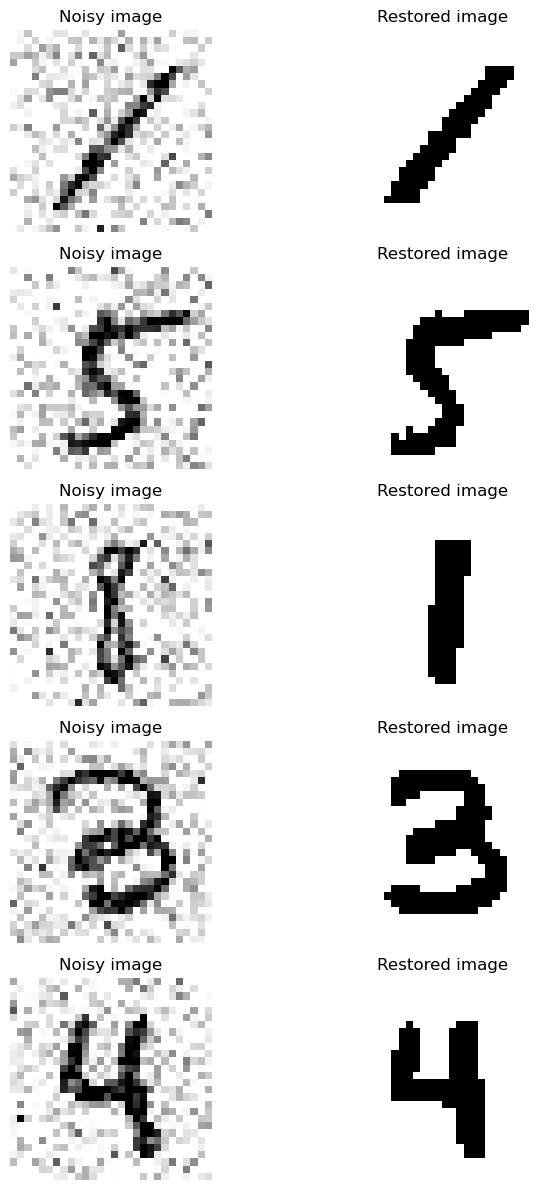

In [5]:
#____________________________ part e ______________________________#
import matplotlib.pyplot as plt

# Plotting 5 samples of noisy and their cleaned image using the model 
fig, axs = plt.subplots(5, 2, figsize=(8, 12))
for i in range(5):
    # Choosing a random noisy image from the test set 
    idx = np.random.choice(X_test.shape[0])
    noisy_img = X_test[idx]

    # Restoring the noisy image using the trained KNN model 
    restored_img = knn.predict(X_test[idx].reshape(1, 784)).reshape(28, 28)

    # Plotting the noisy and restored images side by side 
    axs[i][0].imshow(1-noisy_img.reshape(28, 28), cmap='gray')
    axs[i][0].axis('off')
    axs[i][0].set_title(f"Noisy image")
    axs[i][1].imshow(1-restored_img, cmap='gray')
    axs[i][1].axis('off')
    axs[i][1].set_title("Restored image")
    
plt.tight_layout()
plt.show()
